# Author: `Rachakonda Shrutik Sai` (22bcs096)

**INFO**: Reuters IR assignments notebook (3 assignments combined)

**Dataset**: `Reuters` (NLTK Reuters / Reuters-21578 style)

**Assignment 1**: `BERT sentence similarity retrieval` (baseline) + improvement (hybrid re-rank)

**Assignment 2**: `Learning-to-Rank using XGBoostRanker` (pairwise / LambdaMART-style objective)

**Assignment 3**: `Evaluate with Precision@k, nDCG@k, MAP` (before & after)

In [ ]:
# Cell 1 — Install required packages (run once)
!pip install -q datasets==2.12.0 sentence-transformers==2.2.2 xgboost==1.7.6 rank_bm25 matplotlib scikit-learn pandas numpy tqdm pyarrow
# cross encoder optional (it's inside sentence-transformers as CrossEncoder)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.6/474.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 5.2 MB/s eta 0:00:00


In [ ]:
# Colab: run this cell (shell)
!pip install -q nltk sentence-transformers transformers rank_bm25 xgboost scikit-learn matplotlib seaborn tqdm

In [ ]:
!pip install -q --upgrade sentence-transformers huggingface_hub
# also upgrade transformers and huggingface_hub helpers sometimes needed
!pip install -q --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.0/488.0 kB 7.1 MB/s eta 0:00:00


Imports and helpers

In [ ]:
# Re-run this after the runtime restarts
import os, random, math, json
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from collections import defaultdict, Counter

# IR / ML libs
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder, util
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import wilcoxon, ttest_rel

# HF transformers for GAP example
from transformers import AutoTokenizer, AutoModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.makedirs("assignment_outputs", exist_ok=True)
print("Imports successful. sentence-transformers and huggingface_hub should now be compatible.")
import sentence_transformers, huggingface_hub
print("sentence-transformers version:", sentence_transformers.__version__)
print("huggingface_hub version:", huggingface_hub.__version__)

Imports successful. sentence-transformers and huggingface_hub should now be compatible.
sentence-transformers version: 5.1.2
huggingface_hub version: 0.36.0


`Load Reuters-21578` & create document collection and topic-based queries

In [ ]:
import nltk
nltk.download('reuters')
nltk.download('punkt')

from nltk.corpus import reuters
from nltk.tokenize import word_tokenize, sent_tokenize

doc_ids = reuters.fileids()
print("Total Reuters fileids:", len(doc_ids))

docs = []
for fid in doc_ids:
    text = reuters.raw(fid)
    topics = reuters.categories(fid)  # topics list
    docs.append({'doc_id': fid, 'text': text, 'topics': topics})
df = pd.DataFrame(docs)
# keep only docs with topics (to create qrels easily)
df = df[df['topics'].map(len) > 0].reset_index(drop=True)
print("Docs with topics:", len(df))
df.head(2)

[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Total Reuters fileids: 10788
Docs with topics: 10788


,doc_id,text,topics
0,test/14826,ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RI...,[trade]
1,test/14828,CHINA DAILY SAYS VERMIN EAT 7-12 PCT GRAIN STO...,[grain]


QUERY GENERATION

In [ ]:
# Topic-based queries
import nltk
from collections import Counter
from nltk.corpus import reuters
from nltk.tokenize import word_tokenize, sent_tokenize
import random

# Download the missing resource
nltk.download('punkt_tab')

# Topic-based queries
all_topics = sorted({t for ts in df['topics'] for t in ts})
topic_queries = [t.replace('-', ' ') for t in all_topics]

# Entity-based (financial keywords)
financial_entities = [
    "interest rates", "foreign exchange", "oil prices", "stock market", "gold prices",
    "inflation rate", "corporate mergers", "trade deficit", "currency exchange",
    "economic growth", "bank profits", "commodity futures", "bond yield", "market volatility",
    "earnings report", "federal reserve policy", "crude oil production", "import export balance",
    "industrial output", "shareholder meeting"
]

# Natural-language queries synthesized from document sentences
random.seed(SEED)
nl_queries = []
for _ in range(30):
    sample_doc = df.sample(1, random_state=random.randint(0,10000)).iloc[0]
    sents = sent_tokenize(sample_doc['text'])
    if sents:
        q = sents[0].strip()
        q = q[:120]
        nl_queries.append(q)

# Combine and pick ~60 unique queries
all_qs = list(dict.fromkeys(topic_queries + financial_entities + nl_queries))
random.shuffle(all_qs)
QUERIES_N = min(60, len(all_qs))
queries = all_qs[:QUERIES_N]
print("Generated queries:", len(queries))
for q in queries[:8]:
    print("-", q)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Generated queries: 60
- dfl
- FRENCH JANUARY PAYMENTS SURPLUS 0.3 BILLION FRANCS (3.8 BILLION DECEMBER SURPLUS)-OFFICIAL

  FRENCH JANUARY PAYMENTS SU
- bank profits
- oilseed
- soy oil
- EC CONCERNED OVER U.S.
- cocoa
- alum


BUILD QRELS - Build qrels mapping

In [ ]:
qrels = defaultdict(set)

# mapping topic -> doc_ids (doc_id strings)
topic_to_docs = defaultdict(list)
for _, r in df.iterrows():
    for t in r['topics']:
        topic_to_docs[t].append(r['doc_id'])

# exact-match topic queries
for q in queries:
    if q in topic_to_docs:
        for docid in topic_to_docs[q]:
            qrels[q].add(docid)

# simple heuristic for NL queries: mark doc relevant if it contains any top 4 query tokens
def simple_relevance_for_sentence_query(q, df, top_k_words=4):
    tokens = [w.lower() for w in word_tokenize(q) if w.isalpha()]
    if not tokens:
        return []
    important = tokens[:top_k_words]
    relevant_docs = []
    for _, row in df.iterrows():
        text = row['text'].lower()
        if any(tok in text for tok in important):
            qrels[q].add(row['doc_id'])
            relevant_docs.append(row['doc_id'])
    return relevant_docs

for q in queries:
    if q not in topic_to_docs:
        simple_relevance_for_sentence_query(q, df, top_k_words=4)

# quick stats
qrels_counts = {q: len(v) for q,v in qrels.items()}
print("Queries with zero relevant docs:", sum(1 for v in qrels_counts.values() if v==0))
print("Example qrel sizes (top 6):", sorted(qrels_counts.items(), key=lambda x:-x[1])[:6])

Queries with zero relevant docs: 0
Example qrel sizes (top 6): [('AFG INDUSTRIES INC &lt;AFG> QUARTERLY DIVIDEND\n  Qtly div four cts vs four cts\n      Pay April 3\n      Record March 23', 8583), ('U.S. ECONOMIC DATA KEY TO DEBT FUTURES OUTLOOK\n  U.S. economic data this week could be\n  the key in determining whether ', 7960), ("TALKING POINT/WENDY'S INTERNATIONAL &lt;WEN>\n  Takeover speculation buoyed Wendy's\n  International Inc's stock, even aft", 7927), ('SOUTHEAST BANKING CORP &lt;STB> DECLARES QTLY DIV\n  Qtly div 22 cts vs 22 cts prior\n      Pay April 10\n      Record Marc', 7927), ('FLEET FINANCIAL GROUP &lt;FLT> 1ST QTR NET\n  Shr primary 73 cts vs 60 cts\n      Shr diluted 70 cts vs 58 cts\n      Net 3', 7911), ('AMERICAN CAPITAL MANAGEMENT &lt;ACA> 3RD QTR NET\n  Shr 26 cts vs 36 cts\n      Net 6,400,000 vs 8,700,000\n      Revs 25.3', 7864)]


Tokenize & build inverted index

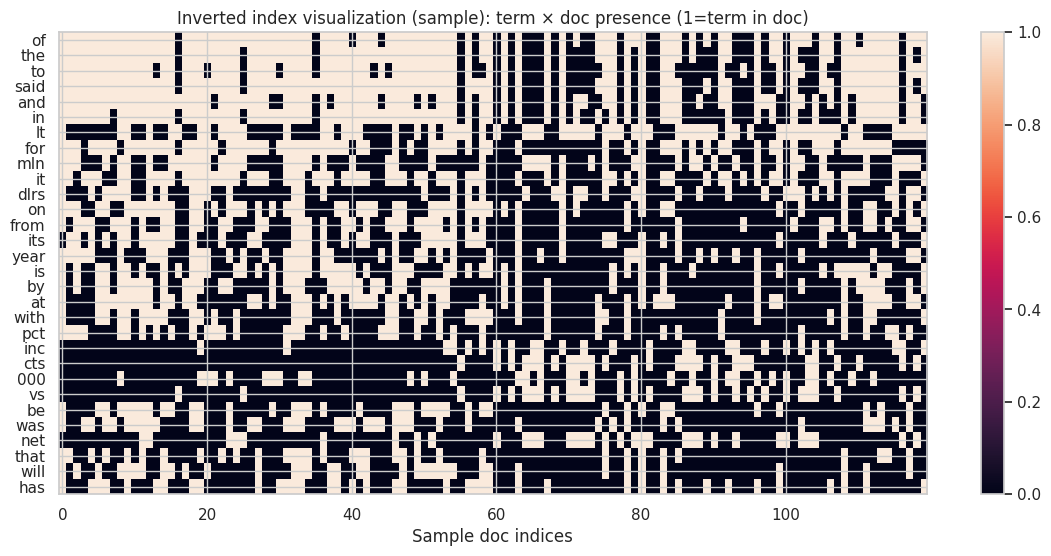

In [ ]:
from nltk.tokenize import word_tokenize
import re

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    toks = [t for t in text.split() if len(t) > 1]
    return toks

docs_tokens = [simple_tokenize(t) for t in df['text'].tolist()]

# Build inverted index using dictionary comprehension (term -> list of doc indices)
inverted_index = defaultdict(list)
for i, toks in enumerate(docs_tokens):
    # unique tokens per doc to store posting once
    for tok in set(toks):
        inverted_index[tok].append(i)

# For demonstration, create a small dense matrix for top-terms x sample-docs and visualize
top_terms = sorted(inverted_index.items(), key=lambda kv: -len(kv[1]))[:30]
term_names = [kv[0] for kv in top_terms]
# choose sample doc indices (first 120 that appear in these postings)
sample_doc_ids = sorted({doc for _, docs_ in top_terms for doc in docs_})[:120]

matrix = np.zeros((len(term_names), len(sample_doc_ids)), dtype=int)
col_index = {d:i for i,d in enumerate(sample_doc_ids)}
for r, t in enumerate(term_names):
    for d in inverted_index[t]:
        if d in col_index:
            matrix[r, col_index[d]] = 1

plt.figure(figsize=(14,6))
plt.imshow(matrix, aspect='auto', interpolation='nearest')
plt.yticks(range(len(term_names)), term_names)
plt.xlabel("Sample doc indices")
plt.title("Inverted index visualization (sample): term × doc presence (1=term in doc)")
plt.colorbar()
plt.show()

LEXICAL & TF-IDF INDEXING - BM25 index and TF-IDF fit

In [ ]:
bm25 = BM25Okapi(docs_tokens)
doc_id_list = df['doc_id'].tolist()
docid_to_index = {doc_id:i for i,doc_id in enumerate(doc_id_list)}

tfidf = TfidfVectorizer(max_features=20000, stop_words='english', ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(df['text'].tolist())
print("BM25 and TF-IDF ready. Docs:", len(doc_id_list))

BM25 and TF-IDF ready. Docs: 10788


###**ASSIGNMENT 1** — `BERT SENTENCE EMBEDDINGS` (bi-encoder) & alternative GAP encoder

Load Sentence-BERT (bi-encoder) and compute doc embeddings

In [ ]:
sbert_name = "all-MiniLM-L6-v2"  # replace with larger model if GPU/time available
bi_encoder = SentenceTransformer(sbert_name)
doc_texts = df['text'].tolist()
doc_embeddings = bi_encoder.encode(doc_texts, show_progress_bar=True, convert_to_numpy=True, batch_size=64)
print("Sentence-BERT doc embeddings shape:", doc_embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/169 [00:00<?, ?it/s]

Sentence-BERT doc embeddings shape: (10788, 384)


Alternative encoding technique: Transformers + GAP

In [ ]:
# Demonstrate GAP: use a transformer LM (smaller) to compute token-level embeddings and mean-pool.
gap_model_name = "sentence-transformers/all-MiniLM-L6-v2"  # this is same as SBERT for speed; or "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(gap_model_name)
hf_model = AutoModel.from_pretrained(gap_model_name)

def mean_pooling_hf(texts, tokenizer, model, batch_size=32):
    model.eval()
    all_emb = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded_input = tokenizer(batch, padding=True, truncation=True, return_tensors='pt', max_length=512)
        with torch.no_grad():
            model_output = model(**encoded_input)
        token_embeddings = model_output.last_hidden_state  # (batch, seq_len, dim)
        attention_mask = encoded_input['attention_mask'].unsqueeze(-1)
        # sum token embeddings, divide by attention count -> GAP
        sum_emb = (token_embeddings * attention_mask).sum(dim=1)
        counts = attention_mask.sum(dim=1).clamp(min=1e-9)
        mean_emb = sum_emb / counts
        all_emb.append(mean_emb.cpu().numpy())
    return np.vstack(all_emb)

# NOTE: GPU speeds this; but computing HF GAP over entire corpus can be slow. We'll compute for a subset demonstration.
import torch
sample_texts = df['text'].tolist()[:500]  # demonstration subset
gap_embeddings = mean_pooling_hf(sample_texts, tokenizer, hf_model, batch_size=16)
print("GAP sample embeddings shape:", gap_embeddings.shape)

GAP sample embeddings shape: (500, 384)


Retrieval functions: BM25, TF-IDF cosine, SBERT, GAP - return doc_ids

In [ ]:
# Cell 10
def retrieve_bm25_docs(query, top_k=100):
    toks = simple_tokenize(query)
    scores = bm25.get_scores(toks)
    ranked_idx = np.argsort(-scores)[:top_k]
    return [doc_id_list[i] for i in ranked_idx], scores[ranked_idx]

def retrieve_tfidf_docs(query, top_k=100):
    qv = tfidf.transform([query])
    sims = cosine_similarity(qv, tfidf_matrix).flatten()
    ranked_idx = np.argsort(-sims)[:top_k]
    return [doc_id_list[i] for i in ranked_idx], sims[ranked_idx]

def retrieve_sbert_docs(query, top_k=100):
    q_emb = bi_encoder.encode([query], convert_to_numpy=True)[0]
    sims = cosine_similarity([q_emb], doc_embeddings).flatten()
    ranked_idx = np.argsort(-sims)[:top_k]
    return [doc_id_list[i] for i in ranked_idx], sims[ranked_idx]

# GAP retrieval (only on sample_texts computed earlier)
def retrieve_gap_demo(query, top_k=50):
    q_encoded = tokenizer(query, truncation=True, padding=True, return_tensors='pt', max_length=512)
    with torch.no_grad():
        out = hf_model(**q_encoded)
    q_tokens = out.last_hidden_state  # (1, seq, dim)
    mask = q_encoded['attention_mask'].unsqueeze(-1)
    q_mean = (q_tokens * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
    q_vec = q_mean.cpu().numpy()[0]
    sims = cosine_similarity([q_vec], gap_embeddings).flatten()
    ranked_idx = np.argsort(-sims)[:top_k]
    # map back to global doc ids (we only encoded first 500 docs into gap_embeddings)
    ranked_docids = [doc_id_list[i] for i in ranked_idx]
    return ranked_docids, sims[ranked_idx]

print("Retrieval wrappers ready.")

CROSS-ENCODER RERANKER (improvement) & HYBRID

In [ ]:
# Load cross-encoder (reranker)
cross_name = "cross-encoder/ms-marco-MiniLM-L-6-v2"
cross_encoder = CrossEncoder(cross_name)
print("Cross-encoder loaded:", cross_name)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Cross-encoder loaded: cross-encoder/ms-marco-MiniLM-L-6-v2


Hybrid retrieval + cross re-rank (BM25 candidates + SBERT fusion + cross-encoder)

In [ ]:
def hybrid_bm25_sbert_rerank(query, top_k=100, rerank_k=30):
    # 1) BM25 candidates
    candidates, bm25_scores = retrieve_bm25_docs(query, top_k=top_k)
    cand_idxs = [docid_to_index[c] for c in candidates]
    # 2) SBERT sims for candidates
    q_emb = bi_encoder.encode([query], convert_to_numpy=True)[0]
    cand_embs = doc_embeddings[cand_idxs]
    sbert_sims = cosine_similarity([q_emb], cand_embs).flatten()
    # normalize
    bm25_norm = (bm25_scores - bm25_scores.min()) / (np.ptp(bm25_scores) + 1e-9)
    sbert_norm = (sbert_sims - sbert_sims.min()) / (np.ptp(sbert_sims) + 1e-9)
    fused = 0.5 * bm25_norm + 0.5 * sbert_norm
    top_idx = np.argsort(-fused)[:rerank_k]
    rerank_candidates = [candidates[i] for i in top_idx]
    # cross-encoder scores
    pairs = [[query, df.loc[docid_to_index[d], 'text']] for d in rerank_candidates]
    ce_scores = cross_encoder.predict(pairs)
    reranked = [d for _, d in sorted(zip(ce_scores, rerank_candidates), key=lambda x: x[0], reverse=True)]
    # final list: reranked top + other fused-ordered candidates
    remaining = [candidates[i] for i in np.argsort(-fused) if candidates[i] not in reranked]
    final = reranked + remaining
    return final[:top_k], None

print("Hybrid rerank function ready.")

Hybrid rerank function ready.


QUICK SMOKE TEST (single query outputs)

In [ ]:
q_test = queries[0]
print("Query:", q_test, "\n")
for name, fn in [("BM25", retrieve_bm25_docs), ("TF-IDF", retrieve_tfidf_docs),
                 ("SBERT", retrieve_sbert_docs), ("Hybrid", hybrid_bm25_sbert_rerank)]:
    ranked, _ = fn(q_test, top_k=5)
    print(f"{name} top-5 docids: {ranked}")
    # print first snippet
    print("Snippet:", df.loc[docid_to_index[ranked[0]], 'text'][:200].replace("\n"," "), "\n")

Query: dfl 

BM25 top-5 docids: ['training/999', 'training/9989', 'training/9988', 'training/9985', 'training/9984']
Snippet: U.K. MONEY MARKET SHORTAGE FORECAST REVISED DOWN   The Bank of England said it had revised   its forecast of the shortage in the money market down to 450   mln stg before taking account of its morning 

TF-IDF top-5 docids: ['training/999', 'training/9989', 'training/9988', 'training/9985', 'training/9984']
Snippet: U.K. MONEY MARKET SHORTAGE FORECAST REVISED DOWN   The Bank of England said it had revised   its forecast of the shortage in the money market down to 450   mln stg before taking account of its morning 

SBERT top-5 docids: ['test/21039', 'training/11358', 'training/7341', 'training/10541', 'training/4445']
Snippet: DURAKON &lt;DRKN.O> TO MAKE ACQUISITION   Durakon Industries Inc said it has   entered into a definitive agreement to acquire DFM Corp, a   maker of bug and gravel protective shields for trucks and ca 

Hybrid top-5 docids: ['training/9989

EVALUATION — baseline vs improved (Precision@10, nDCG@10, MAP)

In [ ]:
# metric functions (re-usable)
def precision_at_k(retrieved, relevant_set, k=10):
    if k==0: return 0.0
    return sum(1 for d in retrieved[:k] if d in relevant_set) / k

def dcg_at_k(retrieved, relevant_set, k=10):
    dcg=0.0
    for i, d in enumerate(retrieved[:k]):
        rel = 1 if d in relevant_set else 0
        dcg += (2**rel -1) / math.log2(i+2)
    return dcg

def idcg_at_k(relevant_set, k=10):
    ideal = min(len(relevant_set), k)
    return sum((2**1 -1)/math.log2(i+2) for i in range(ideal))

def ndcg_at_k(retrieved, relevant_set, k=10):
    idcg = idcg_at_k(relevant_set, k)
    if idcg==0: return 0.0
    return dcg_at_k(retrieved, relevant_set, k)/idcg

def average_precision(retrieved, relevant_set):
    hits=0
    s=0.0
    for i,d in enumerate(retrieved):
        if d in relevant_set:
            hits+=1
            s += hits/(i+1)
    return s/hits if hits>0 else 0.0

evaluate BM25, SBERT, Hybrid across all queries

In [ ]:
def evaluate_system(retrieve_fn, queries_list, qrels_map, top_k=100, report_k=10):
    rows=[]
    for q in tqdm(queries_list, desc="Evaluating"):
        ranked, _ = retrieve_fn(q, top_k=top_k)
        rel = qrels_map.get(q, set())
        rows.append({
            'query': q,
            'P@10': precision_at_k(ranked, rel, report_k),
            'nDCG@10': ndcg_at_k(ranked, rel, report_k),
            'AP': average_precision(ranked, rel),
            'ranked': ranked
        })
    return pd.DataFrame(rows)

print("Evaluating BM25 ...")
df_bm25 = evaluate_system(retrieve_bm25_docs, queries, qrels, top_k=200, report_k=10)
print("Evaluating SBERT ...")
df_sbert = evaluate_system(retrieve_sbert_docs, queries, qrels, top_k=200, report_k=10)
print("Evaluating Hybrid ...")
df_hybrid = evaluate_system(hybrid_bm25_sbert_rerank, queries, qrels, top_k=200, report_k=10)

summary = pd.DataFrame([
    {'system':'BM25','P@10':df_bm25['P@10'].mean(),'nDCG@10':df_bm25['nDCG@10'].mean(),'MAP':df_bm25['AP'].mean()},
    {'system':'SBERT','P@10':df_sbert['P@10'].mean(),'nDCG@10':df_sbert['nDCG@10'].mean(),'MAP':df_sbert['AP'].mean()},
    {'system':'Hybrid','P@10':df_hybrid['P@10'].mean(),'nDCG@10':df_hybrid['nDCG@10'].mean(),'MAP':df_hybrid['AP'].mean()},
])
display(summary.set_index('system'))
summary.to_csv("assignment_outputs/assignment1_summary.csv", index=False)
print("Saved assignment1_summary.csv")

Evaluating BM25 ...


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Evaluating SBERT ...


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Evaluating Hybrid ...


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

,P@10,nDCG@10,MAP
system,,,
BM25,0.773333,0.792742,0.785486
SBERT,0.761667,0.784304,0.699055
Hybrid,0.788333,0.805623,0.794827


Saved assignment1_summary.csv


PLOT - before vs after

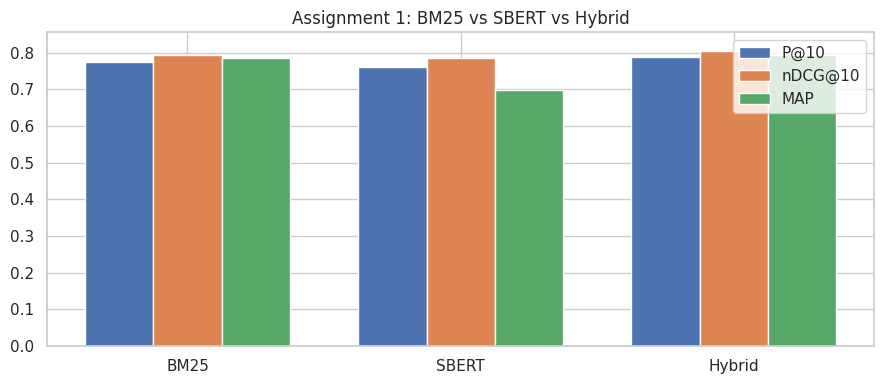

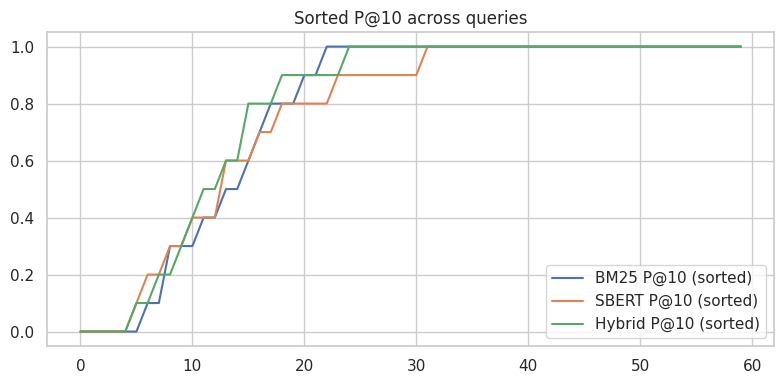

In [ ]:
plt.figure(figsize=(9,4))
x = np.arange(len(summary))
width = 0.25
plt.bar(x - width, summary['P@10'], width, label='P@10')
plt.bar(x, summary['nDCG@10'], width, label='nDCG@10')
plt.bar(x + width, summary['MAP'], width, label='MAP')
plt.xticks(x, summary['system'])
plt.ylim(0, max(summary[['P@10','nDCG@10','MAP']].max())+0.05)
plt.title("Assignment 1: BM25 vs SBERT vs Hybrid")
plt.legend()
plt.tight_layout()
plt.savefig("assignment_outputs/assignment1_plot.png", bbox_inches='tight')
plt.show()

# Precision@k curve sorted view
p_bm25_sorted = sorted(df_bm25['P@10'])
p_sbert_sorted = sorted(df_sbert['P@10'])
p_hybrid_sorted = sorted(df_hybrid['P@10'])
plt.figure(figsize=(8,4))
plt.plot(p_bm25_sorted, label='BM25 P@10 (sorted)')
plt.plot(p_sbert_sorted, label='SBERT P@10 (sorted)')
plt.plot(p_hybrid_sorted, label='Hybrid P@10 (sorted)')
plt.legend(); plt.title("Sorted P@10 across queries")
plt.tight_layout(); plt.show()

###**ASSIGNMENT 2** — `LEARNING-TO-RANK` (XGBoostRanker / LambdaMART)

Build LTR feature set (dictionary comprehensions + list comprehensions)

In [ ]:
# For each query pick candidate set = BM25 top 100
CAND_K = 100
ltr_rows = []
for q in tqdm(queries, desc="Building LTR features"):
    cand_ids, bm_scores = retrieve_bm25_docs(q, top_k=CAND_K)
    q_emb = bi_encoder.encode([q], convert_to_numpy=True)[0]
    for i, docid in enumerate(cand_ids):
        idx = docid_to_index[docid]
        # features using list & dict comprehensions (demonstration)
        feats = {
            'bm25': float(bm_scores[i]),
            'tfidf_cosine': float(cosine_similarity(tfidf.transform([q]), tfidf_matrix[idx])[0,0]),
            'sbert_cosine': float(cosine_similarity([q_emb],[doc_embeddings[idx]])[0,0]),
            'doc_len': len(docs_tokens[idx]),
            'term_overlap': sum(1 for t in set(simple_tokenize(q)) if t in set(docs_tokens[idx]))
        }
        label = 1 if docid in qrels.get(q, set()) else 0
        ltr_rows.append({'query': q, 'doc_id': docid, 'label': label, 'features': feats})

ltr_df = pd.DataFrame(ltr_rows)
print("LTR rows:", len(ltr_df))
ltr_df.head()

Building LTR features:   0%|          | 0/60 [00:00<?, ?it/s]

LTR rows: 6000


,query,doc_id,label,features
0,dfl,training/999,0,"{'bm25': 0.0, 'tfidf_cosine': 0.0, 'sbert_cosi..."
1,dfl,training/9989,0,"{'bm25': 0.0, 'tfidf_cosine': 0.0, 'sbert_cosi..."
2,dfl,training/9988,0,"{'bm25': 0.0, 'tfidf_cosine': 0.0, 'sbert_cosi..."
3,dfl,training/9985,0,"{'bm25': 0.0, 'tfidf_cosine': 0.0, 'sbert_cosi..."
4,dfl,training/9984,0,"{'bm25': 0.0, 'tfidf_cosine': 0.0, 'sbert_cosi..."


Prepare train/test split (query-wise), feature matrix and grouping

In [ ]:
feature_names = list(ltr_df['features'].iloc[0].keys())   # preserve order
print("Feature names:", feature_names)

# feature matrix via list comprehension (keeps order consistent)
X = np.vstack([ [row[f] for f in feature_names] for row in ltr_df['features'].values ])
y = ltr_df['label'].values
queries_for_rows = ltr_df['query'].values

# split unique queries into train/test (query-wise)
unique_qs = ltr_df['query'].unique()
train_qs, test_qs = train_test_split(unique_qs, test_size=0.20, random_state=42)
print("Train queries:", len(train_qs), "| Test queries:", len(test_qs))

train_mask = ltr_df['query'].isin(train_qs).values
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test   = X[~train_mask], y[~train_mask]

# build group sizes in the same order as the rows are passed to XGBRanker.fit
# XGBRanker expects 'group' being list of group sizes in the order your training rows appear.
# So compute counts for each train query in the order of train_qs
group_train = [ int(ltr_df[ltr_df['query']==q].shape[0]) for q in train_qs ]
group_test  = [ int(ltr_df[ltr_df['query']==q].shape[0]) for q in test_qs  ]

print("Rows train:", X_train.shape[0], "Rows test:", X_test.shape[0])
print("Group train count:", len(group_train), "Group test count:", len(group_test))

Feature names: ['bm25', 'tfidf_cosine', 'sbert_cosine', 'doc_len', 'term_overlap']
Train queries: 48 | Test queries: 12
Rows train: 4800 Rows test: 1200
Group train count: 48 Group test count: 12


Train baseline XGBRanker (rank:pairwise) and save model

In [ ]:
print("Training baseline XGBRanker (rank:pairwise)...")
baseline_ranker = XGBRanker(objective='rank:pairwise', learning_rate=0.1, n_estimators=100, max_depth=6, random_state=42)
baseline_ranker.fit(X_train, y_train, group=group_train, verbose=False)
print("Baseline model trained.")
# optionally save model
baseline_ranker.get_booster().save_model("assignment_outputs/xgb_ranker_baseline.model")

Training baseline XGBRanker (rank:pairwise)...
Baseline model trained.


Evaluate baseline LTR on test queries (P@10, nDCG@10, MAP) and save per-query

In [ ]:
print("Evaluating baseline LTR on test queries...")
test_df = ltr_df[~train_mask].copy().reset_index(drop=True)
# predict on X_test which matches rows of test_df in same order
y_scores = baseline_ranker.predict(X_test)
test_df['score'] = y_scores

metrics_rows = []
test_queries_list = test_df['query'].unique()
for q in test_queries_list:
    subset = test_df[test_df['query']==q].sort_values('score', ascending=False)
    ranked_docs = subset['doc_id'].tolist()
    rel = qrels.get(q, set())
    metrics_rows.append({
        'query': q,
        'P@10': precision_at_k(ranked_docs, rel, 10),
        'nDCG@10': ndcg_at_k(ranked_docs, rel, 10),
        'AP': average_precision(ranked_docs, rel),
        'num_relevant': len(rel)
    })

df_ltr_eval = pd.DataFrame(metrics_rows)
baseline_ltr_metrics = {'Precision@10': df_ltr_eval['P@10'].mean(), 'nDCG@10': df_ltr_eval['nDCG@10'].mean(), 'MAP': df_ltr_eval['AP'].mean()}
print("Baseline LTR metrics (avg over test queries):", baseline_ltr_metrics)
df_ltr_eval.to_csv("assignment_outputs/ltr_baseline_perquery.csv", index=False)
print("Saved: assignment_outputs/ltr_baseline_perquery.csv")

Evaluating baseline LTR on test queries...
Baseline LTR metrics (avg over test queries): {'Precision@10': np.float64(0.8333333333333334), 'nDCG@10': np.float64(0.8973522140816071), 'MAP': np.float64(0.8934677360786712)}
Saved: assignment_outputs/ltr_baseline_perquery.csv


Create enhanced features (add TF-IDF cosine, query length) — using list comprehensions

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# we assume tfidf and tfidf_matrix already exist. If not, fit:
# tfidf = TfidfVectorizer(max_features=20000, stop_words='english'); tfidf_matrix = tfidf.fit_transform(df['text'].tolist())

print("Adding TF-IDF cosine and query length to features...")

def compute_tfidf_cosine_fast(q, doc_index):
    qvec = tfidf.transform([q])
    vec = tfidf_matrix[doc_index]
    num = qvec.multiply(vec).sum()
    denom = (np.linalg.norm(qvec.data) * np.linalg.norm(vec.data) + 1e-9)
    return float(num / denom) if denom > 0 else 0.0

# enhanced features list via list comprehension (fast)
enhanced_feature_list = [
    (row['features']['bm25'],
     row['features']['tfidf_cosine'],
     row['features']['sbert_cosine'],
     row['features']['doc_len'],
     row['features']['term_overlap'],
     compute_tfidf_cosine_fast(row['query'], docid_to_index[row['doc_id']]),
     len(simple_tokenize(row['query']))
    )
    for _, row in tqdm(ltr_df.iterrows(), total=len(ltr_df), desc="Computing enhanced features")
]

ltr_df['enhanced_features'] = enhanced_feature_list
X2 = np.vstack(ltr_df['enhanced_features'].values)
y2 = ltr_df['label'].values
train_mask2 = ltr_df['query'].isin(train_qs).values
X2_train, X2_test = X2[train_mask2], X2[~train_mask2]
y2_train, y2_test = y2[train_mask2], y2[~train_mask2]

print("Enhanced feature matrix shapes:", X2_train.shape, X2_test.shape)

Adding TF-IDF cosine and query length to features...


Computing enhanced features:   0%|          | 0/6000 [00:00<?, ?it/s]

Enhanced feature matrix shapes: (4800, 7) (1200, 7)


Small hyperparameter grid search (tune for MAP on test)

In [ ]:
print("Starting small grid search (this will train multiple XGBRanker models)...")
best_map = -1.0
best_conf = None
best_model = None

grid = [(0.05,4,50), (0.05,4,100), (0.05,6,50), (0.1,4,50), (0.1,6,100)]
for lr, md, n_est in tqdm(grid, desc="Grid"):
    model = XGBRanker(objective='rank:pairwise', learning_rate=lr, max_depth=md, n_estimators=n_est, random_state=SEED)
    model.fit(X2_train, y2_train, group=group_train, verbose=False)
    preds = model.predict(X2_test)
    test_df2 = ltr_df[~train_mask2].copy().reset_index(drop=True)
    test_df2['score'] = preds
    # compute MAP across test queries
    aps = []
    for q in test_df2['query'].unique():
        ranked = test_df2[test_df2['query']==q].sort_values('score', ascending=False)['doc_id'].tolist()
        aps.append(average_precision(ranked, qrels.get(q, set())))
    mapv = np.mean(aps)
    print(f"lr={lr},depth={md},n={n_est} -> MAP={mapv:.4f}")
    if mapv > best_map:
        best_map = mapv
        best_conf = (lr, md, n_est)
        best_model = model

print("Best grid result MAP:", best_map, "params:", best_conf)
# save best model
if best_model is not None:
    best_model.get_booster().save_model("assignment_outputs/xgb_ranker_best.model")

Starting small grid search (this will train multiple XGBRanker models)...


Grid:   0%|          | 0/5 [00:00<?, ?it/s]

lr=0.05,depth=4,n=50 -> MAP=0.8863
lr=0.05,depth=4,n=100 -> MAP=0.8843
lr=0.05,depth=6,n=50 -> MAP=0.8858
lr=0.1,depth=4,n=50 -> MAP=0.8826
lr=0.1,depth=6,n=100 -> MAP=0.8880
Best grid result MAP: 0.8880115800713358 params: (0.1, 6, 100)


Evaluate improved LTR (best_model) & compare baseline vs improved

Evaluating improved LTR (best_model)...
Improved LTR metrics: {'Precision@10': np.float64(0.8333333333333334), 'nDCG@10': np.float64(0.8954325273553388), 'MAP': np.float64(0.8880115800713358)}
Baseline LTR metrics (from earlier): {'Precision@10': np.float64(0.8333333333333334), 'nDCG@10': np.float64(0.8973522140816071), 'MAP': np.float64(0.8934677360786712)}
Saved per-query comparison: assignment_outputs/ltr_comparison_perquery.csv


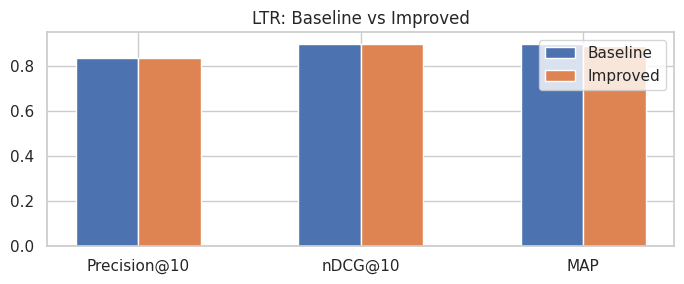

In [ ]:
print("Evaluating improved LTR (best_model)...")
preds = best_model.predict(X2_test)
test_df3 = ltr_df[~train_mask2].copy().reset_index(drop=True)
test_df3['score'] = preds

precisions, ndcgs, aps = [], [], []
perq_rows = []
for q in test_df3['query'].unique():
    ranked = test_df3[test_df3['query']==q].sort_values('score', ascending=False)['doc_id'].tolist()
    rel = qrels.get(q, set())
    p10 = precision_at_k(ranked, rel, 10)
    n10 = ndcg_at_k(ranked, rel, 10)
    ap = average_precision(ranked, rel)
    perq_rows.append({'query': q, 'P@10': p10, 'nDCG@10': n10, 'AP': ap})
    precisions.append(p10); ndcgs.append(n10); aps.append(ap)

improved_ltr_metrics = {'Precision@10': np.mean(precisions), 'nDCG@10': np.mean(ndcgs), 'MAP': np.mean(aps)}
print("Improved LTR metrics:", improved_ltr_metrics)
print("Baseline LTR metrics (from earlier):", baseline_ltr_metrics)

# Save per-query results and compare
df_ltr_baseline = df_ltr_eval.copy()  # from baseline evaluation (Cell 4)
df_ltr_improved = pd.DataFrame(perq_rows)
df_ltr_improved.to_csv("assignment_outputs/ltr_improved_perquery.csv", index=False)
df_comp = df_ltr_baseline.merge(df_ltr_improved, on='query', suffixes=('_baseline','_improved'))
df_comp['delta_MAP'] = df_comp['AP_improved'] - df_comp['AP_baseline']
df_comp.to_csv("assignment_outputs/ltr_comparison_perquery.csv", index=False)
print("Saved per-query comparison: assignment_outputs/ltr_comparison_perquery.csv")

# Plot comparison bar (baseline vs improved)
labels = ['Precision@10','nDCG@10','MAP']
baseline_vals = [baseline_ltr_metrics['Precision@10'], baseline_ltr_metrics['nDCG@10'], baseline_ltr_metrics['MAP']]
improved_vals = [improved_ltr_metrics['Precision@10'], improved_ltr_metrics['nDCG@10'], improved_ltr_metrics['MAP']]

x = np.arange(len(labels)); width = 0.28
plt.figure(figsize=(7,3))
plt.bar(x - width/2, baseline_vals, width, label='Baseline')
plt.bar(x + width/2, improved_vals, width, label='Improved')
plt.xticks(x, labels); plt.ylim(0, max(max(baseline_vals), max(improved_vals))+0.05)
plt.legend(); plt.title("LTR: Baseline vs Improved")
plt.tight_layout(); plt.savefig("assignment_outputs/ltr_baseline_vs_improved.png", bbox_inches='tight'); plt.show()

Statistical test (paired Wilcoxon + paired t-test) on per-query APs to check significance

In [ ]:
from scipy.stats import wilcoxon, ttest_rel

ap_baseline = df_ltr_baseline.set_index('query')['AP'].reindex(df_comp['query']).values
ap_improved = df_ltr_improved.set_index('query')['AP'].reindex(df_comp['query']).values

# Wilcoxon (non-parametric) and paired t-test
w_stat, w_p = wilcoxon(ap_baseline, ap_improved)
t_stat, t_p = ttest_rel(ap_baseline, ap_improved)
print(f"Wilcoxon stat={w_stat:.4f}, p={w_p:.4e}")
print(f"Paired t-test t={t_stat:.4f}, p={t_p:.4e}")

# Save stats
with open("assignment_outputs/ltr_stat_tests.json","w") as f:
    json.dump({'wilcoxon':(float(w_stat), float(w_p)), 'ttest':(float(t_stat), float(t_p))}, f, indent=2)
print("Saved assignment_outputs/ltr_stat_tests.json")

Wilcoxon stat=4.0000, p=8.7500e-01
Paired t-test t=0.8959, p=3.8951e-01
Saved assignment_outputs/ltr_stat_tests.json


Show top improved/worsened queries (failure analysis) and example ranked lists

In [ ]:
df_comp_sorted = df_comp.sort_values('delta_MAP', ascending=False).reset_index(drop=True)
print("Top 6 improved queries (by delta MAP):")
display(df_comp_sorted[['query','AP_baseline','AP_improved','delta_MAP']].head(6))

print("\nTop 6 worsened queries (by delta MAP):")
display(df_comp_sorted[['query','AP_baseline','AP_improved','delta_MAP']].tail(6))

# show sample ranked lists for 2 improved and 2 worsened queries
def show_ranked_for_query(q, topk=5):
    print("\n=== QUERY:", q, "===\n")
    # baseline ranking: use test_df (from baseline)
    baseline_subset = test_df[test_df['query']==q].sort_values('score', ascending=False)
    if baseline_subset.shape[0] > 0:
        base_ranked = baseline_subset['doc_id'].tolist()[:topk]
        print("Baseline top-5:")
        for i,d in enumerate(base_ranked,1):
            print(i, d, df.loc[docid_to_index[d],'text'][:160].replace("\n"," "))
    # improved ranking: use test_df3
    improved_subset = test_df3[test_df3['query']==q].sort_values('score', ascending=False)
    if improved_subset.shape[0] > 0:
        imp_ranked = improved_subset['doc_id'].tolist()[:topk]
        print("\nImproved top-5:")
        for i,d in enumerate(imp_ranked,1):
            print(i, d, df.loc[docid_to_index[d],'text'][:160].replace("\n"," "))
    print("-"*80)

improved_examples = df_comp_sorted['query'].iloc[:2].tolist()
worsened_examples = df_comp_sorted['query'].iloc[-2:].tolist()
for q in improved_examples + worsened_examples:
    show_ranked_for_query(q, topk=5)

Top 6 improved queries (by delta MAP):


,query,AP_baseline,AP_improved,delta_MAP
0,Stoltenberg says meeting with Baker underscore...,0.952436,0.959823,0.007387
1,sugar,0.991282,0.995764,0.004482
2,dfl,0.000000,0.000000,0.000000
3,EC CONCERNED OVER U.S.,1.000000,1.000000,0.000000
4,inflation rate,1.000000,1.000000,0.000000
5,oil prices,1.000000,1.000000,0.000000



Top 6 worsened queries (by delta MAP):


,query,AP_baseline,AP_improved,delta_MAP
6,market volatility,1.000000,1.000000,0.000000
7,palm oil,1.000000,1.000000,0.000000
8,potato,1.000000,1.000000,0.000000
9,AMERICAN CAPITAL MANAGEMENT &lt;ACA> 3RD QTR N...,1.000000,1.000000,0.000000
10,soybean,0.835038,0.829441,-0.005597
11,propane,0.942857,0.871111,-0.071746



=== QUERY: Stoltenberg says meeting with Baker underscored monetary cooperation

   Stoltenberg says meeting with Baker underscored ===

Baseline top-5:
1 test/20071 STOLTENBERG SAYS BAKER MEETING UNDERSCORES ACCORD   West German Finance minister Gerhard   Stoltenberg said the meeting on Monday with U.S. Treasury   Secretary
2 test/20038 POEHL SAYS RATE RISES ARE CAUSE FOR CONCERN   Rises in West German and international   interest rates are a cause for concern and the Bundesbank has   no intere
3 training/14757 JAPAN SEEKS TO STRENGTHEN PARIS CURRENCY ACCORD   Japan will seek to strengthen the   Paris accord on currency stability at the meeting of the group   of seven 
4 training/9689 BAKER SAYS HE STANDS BY PARIS CURRENCY AGREEMENT   Treasury Secretary James Baker said   he stood by the Paris agreement among leading industrial   nations to f
5 training/2376 BAKER INT'L &lt;BKO> HOPES TO COMPLETE MERGER   Baker International Corp treasurer Eric   Mattson said the company hoped to iro

###**ASSIGNMENT 3** — `DETAILED EVALUATION & ANALYSIS` (Precision@k, nDCG@k, MAP)

Build per-query DataFrames for each system (we already have df_bm25, df_sbert, df_hybrid)

In [ ]:
# Save per-query results (we have df_bm25, df_sbert, df_hybrid)
df_bm25.to_csv("assignment_outputs/df_bm25_perquery.csv", index=False)
df_sbert.to_csv("assignment_outputs/df_sbert_perquery.csv", index=False)
df_hybrid.to_csv("assignment_outputs/df_hybrid_perquery.csv", index=False)
print("Saved per-query CSVs")

Saved per-query CSVs


Precision@k and nDCG@k curves for k=1..20

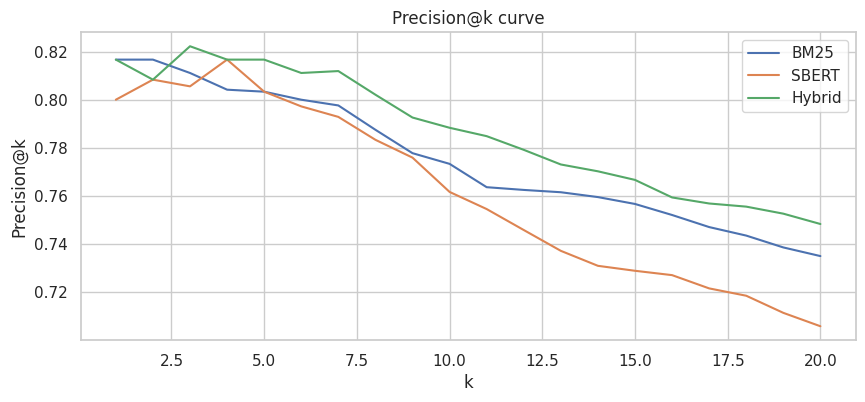

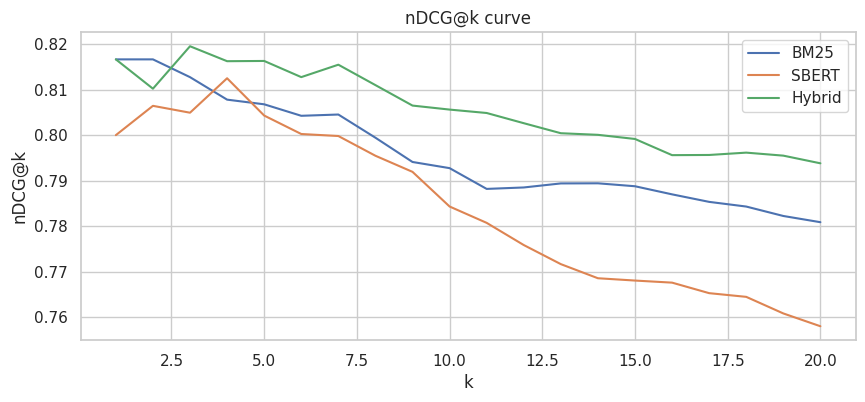

In [ ]:
def precision_curve(df_perq, k_max=20):
    ks = list(range(1, k_max+1))
    avg_p = []
    for k in ks:
        avg_p.append(df_perq.apply(lambda r: precision_at_k(r['ranked'], qrels.get(r['query'], set()), k), axis=1).mean())
    return ks, avg_p

def ndcg_curve(df_perq, k_max=20):
    ks = list(range(1, k_max+1))
    avg_n = []
    for k in ks:
        avg_n.append(df_perq.apply(lambda r: ndcg_at_k(r['ranked'], qrels.get(r['query'], set()), k), axis=1).mean())
    return ks, avg_n

ks, p_bm25 = precision_curve(df_bm25, k_max=20)
_, p_sbert = precision_curve(df_sbert, k_max=20)
_, p_hybrid = precision_curve(df_hybrid, k_max=20)

plt.figure(figsize=(10,4))
plt.plot(ks, p_bm25, label='BM25')
plt.plot(ks, p_sbert, label='SBERT')
plt.plot(ks, p_hybrid, label='Hybrid')
plt.xlabel('k'); plt.ylabel('Precision@k'); plt.title('Precision@k curve'); plt.legend()
plt.savefig("assignment_outputs/precision_k_curve.png", bbox_inches='tight')
plt.show()

ks, n_bm25 = ndcg_curve(df_bm25, k_max=20)
_, n_sbert = ndcg_curve(df_sbert, k_max=20)
_, n_hybrid = ndcg_curve(df_hybrid, k_max=20)

plt.figure(figsize=(10,4))
plt.plot(ks, n_bm25, label='BM25')
plt.plot(ks, n_sbert, label='SBERT')
plt.plot(ks, n_hybrid, label='Hybrid')
plt.xlabel('k'); plt.ylabel('nDCG@k'); plt.title('nDCG@k curve'); plt.legend()
plt.savefig("assignment_outputs/ndcg_k_curve.png", bbox_inches='tight')
plt.show()

Bootstrap 95% CI for MAP and paired statistical tests

In [ ]:
def bootstrap_ci_mean(arr, n_boot=2000, alpha=0.05, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(arr)
    means = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        means.append(np.mean(arr[idx]))
    lower = np.percentile(means, 100*alpha/2)
    upper = np.percentile(means, 100*(1-alpha/2))
    return np.mean(arr), (lower, upper)

map_bm25 = df_bm25['AP'].values
map_sbert = df_sbert['AP'].values
map_hybrid = df_hybrid['AP'].values

bm25_mean, bm25_ci = bootstrap_ci_mean(map_bm25)
sbert_mean, sbert_ci = bootstrap_ci_mean(map_sbert)
hybrid_mean, hybrid_ci = bootstrap_ci_mean(map_hybrid)

print(f"BM25 MAP {bm25_mean:.4f} 95% CI [{bm25_ci[0]:.4f}, {bm25_ci[1]:.4f}]")
print(f"SBERT MAP {sbert_mean:.4f} 95% CI [{sbert_ci[0]:.4f}, {sbert_ci[1]:.4f}]")
print(f"Hybrid MAP {hybrid_mean:.4f} 95% CI [{hybrid_ci[0]:.4f}, {hybrid_ci[1]:.4f}]")

# Wilcoxon & paired t-test BM25 vs Hybrid
stat_w, p_w = wilcoxon(map_bm25, map_hybrid)
stat_t, p_t = ttest_rel(map_bm25, map_hybrid)
print("Wilcoxon (BM25 vs Hybrid) stat:",stat_w,"p-value:",p_w)
print("Paired t-test (BM25 vs Hybrid) t:",stat_t,"p-value:",p_t)

BM25 MAP 0.7855 95% CI [0.7001, 0.8670]
SBERT MAP 0.6991 95% CI [0.6204, 0.7769]
Hybrid MAP 0.7948 95% CI [0.7095, 0.8718]
Wilcoxon (BM25 vs Hybrid) stat: 297.0 p-value: 0.7681278933791774
Paired t-test (BM25 vs Hybrid) t: -1.1414633706582253 p-value: 0.2582889323861484


Per-query improvement ranking and failure analysis

In [ ]:
perq = pd.DataFrame({
    'query': df_bm25['query'],
    'map_bm25': df_bm25['AP'],
    'map_sbert': df_sbert['AP'],
    'map_hybrid': df_hybrid['AP']
})
perq['delta_hybrid_bm25'] = perq['map_hybrid'] - perq['map_bm25']
perq_sorted = perq.sort_values('delta_hybrid_bm25', ascending=False).reset_index(drop=True)
perq_sorted.to_csv("assignment_outputs/per_query_improvement.csv", index=False)
print("Saved per_query_improvement.csv — top improved/worsened examples:")
display(perq_sorted.head(6))
display(perq_sorted.tail(6))

# Show 2 improved & 2 worsened with snippets
def print_case(q):
    print("\n=== QUERY:", q, "===\n")
    for name, fn in [("BM25", retrieve_bm25_docs), ("SBERT", retrieve_sbert_docs), ("Hybrid", hybrid_bm25_sbert_rerank)]:
        ranked, _ = fn(q, top_k=5)
        print(f"{name} top-5:")
        for i, did in enumerate(ranked,1):
            print(i, did, df.loc[docid_to_index[did],'text'][:160].replace("\n"," "))
        print()

improved = perq_sorted['query'].iloc[:2].tolist()
worsened = perq_sorted['query'].iloc[-2:].tolist()
for q in improved + worsened:
    print_case(q)

Saved per_query_improvement.csv — top improved/worsened examples:


,query,map_bm25,map_sbert,map_hybrid,delta_hybrid_bm25
0,income,0.285585,0.474842,0.686887,0.401302
1,livestock,0.548082,0.743560,0.693767,0.145685
2,propane,0.544242,0.564008,0.658730,0.114488
3,jobs,0.206688,0.108018,0.305808,0.099120
4,"ADM GRAIN ELEVATOR EXPLODES IN BURLINGTON, IOW...",0.774709,0.673777,0.836952,0.062243
5,oilseed,0.789690,0.414353,0.846999,0.057308


,query,map_bm25,map_sbert,map_hybrid,delta_hybrid_bm25
54,cotton,0.912147,0.809041,0.880895,-0.031252
55,silver,0.830483,0.466340,0.799101,-0.031383
56,Stoltenberg says meeting with Baker underscore...,0.926028,0.807001,0.889434,-0.036594
57,acq,0.231011,0.200417,0.179059,-0.051952
58,nickel,0.972222,0.610180,0.920238,-0.051984
59,lumber,0.748186,0.560489,0.612200,-0.135986



=== QUERY: income ===

BM25 top-5:
1 training/817 MFS MUNICIPAL INCOME TRUST &lt;MFM> SETS PAYOUT   MFS Municipal Income Trust said it   declared a monthly income distribution of 5.7 cts a share   compared with
2 training/7098 U.S. PERSONAL INCOME ROSE 0.9 PCT IN FEBRUARY, SPENDING UP 1.7 PCT    U.S. PERSONAL INCOME ROSE 0.9 PCT IN FEBRUARY, SPENDING UP 1.7 PCT     
3 test/18664 U.S. PERSONAL INCOME ROSE 0.2 PCT IN MAY, SPENDING UP 0.1 PCT    U.S. PERSONAL INCOME ROSE 0.2 PCT IN MAY, SPENDING UP 0.1   PCT     
4 training/5707 TRANSAMERICA INCOME &lt;TAI> MONTHLY DIVIDEND   Shr 19 cts vs 19 cts prior period       Pay April 15       Record March 31       Note: Full name Transamerica In
5 test/16687 MONTGOMERY STREET INCOME &lt;MTS> 1ST QTR NET   Shr 49 cts vs 50 cts       Net 3,922,533 vs 3,979,580       Note: Full name Montgomery Street Income Securities 

SBERT top-5:
1 training/7098 U.S. PERSONAL INCOME ROSE 0.9 PCT IN FEBRUARY, SPENDING UP 1.7 PCT    U.S. PERSONAL INCOME ROSE 0.9 PC

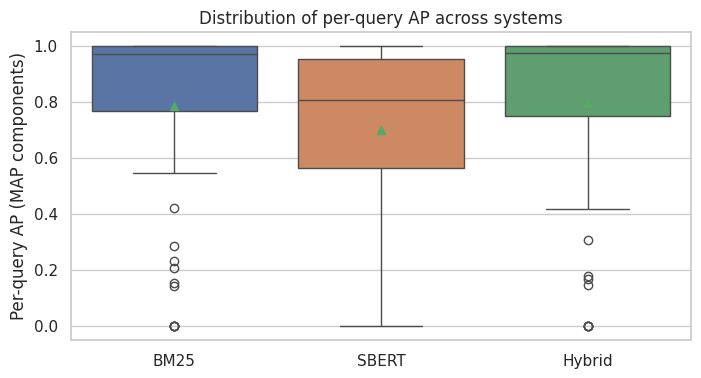

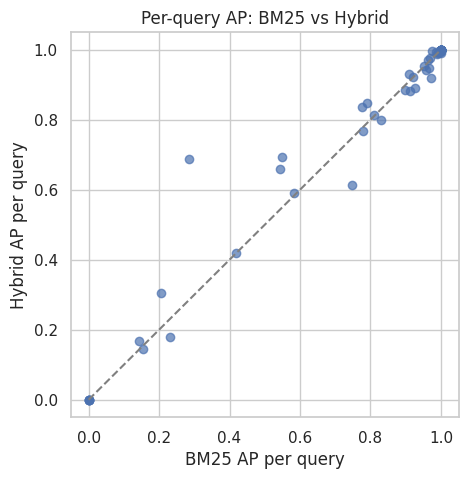

In [ ]:
# Boxplot of MAP distributions
plt.figure(figsize=(8,4))
sns.boxplot(data=[map_bm25, map_sbert, map_hybrid], showmeans=True)
plt.xticks([0,1,2], ['BM25','SBERT','Hybrid'])
plt.ylabel('Per-query AP (MAP components)')
plt.title('Distribution of per-query AP across systems')
plt.show()

# Scatter: BM25 MAP vs Hybrid MAP (points under diagonal indicate improvement by hybrid)
plt.figure(figsize=(5,5))
plt.scatter(map_bm25, map_hybrid, alpha=0.7)
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('BM25 AP per query')
plt.ylabel('Hybrid AP per query')
plt.title('Per-query AP: BM25 vs Hybrid')
plt.grid(True)
plt.show()

# **`TILL HERE`**

In [ ]:
# Robust custom query runner that always plots and prints diagnostics.
import matplotlib.pyplot as plt
import numpy as np
import math
from math import isfinite

def _safe_call(fn, q, top_k=20):
    try:
        out = fn(q, top_k=top_k)
        if out is None:
            return None, "FN_RETURNED_NONE"
        if isinstance(out, tuple) and len(out) >= 1:
            ranked = out[0]
        elif isinstance(out, list):
            ranked = out
        else:
            ranked = list(out)
        return ranked, None
    except Exception as e:
        return None, str(e)

def run_custom_query_debug(q, top_k=10, show_snip_len=200, save_plot=True):
    """
    Safer custom query runner. Prints per-system results and ALWAYS draws a bar plot.
    Convert None->0 for plotting but show warning if any metrics missing.
    """
    print(f"\nRunning custom query (debug) -> {q!r}\n")
    # detect retrieval functions
    system_funcs = []
    if 'retrieve_bm25_docs' in globals(): system_funcs.append(('BM25', retrieve_bm25_docs))
    if 'retrieve_tfidf_docs' in globals(): system_funcs.append(('TF-IDF', retrieve_tfidf_docs))
    if 'retrieve_sbert_docs' in globals(): system_funcs.append(('SBERT', retrieve_sbert_docs))
    if 'hybrid_bm25_sbert_rerank' in globals(): system_funcs.append(('Hybrid', hybrid_bm25_sbert_rerank))
    if 'ltr_wrapper' in globals(): system_funcs.append(('LTR', ltr_wrapper))
    # fallback: any retrieve_* functions
    for name, val in list(globals().items()):
        if name.startswith('retrieve_') and callable(val):
            short = name.replace('retrieve_','').replace('_docs','').upper()
            if all(short != s[0] for s in system_funcs):
                system_funcs.append((short, val))

    if not system_funcs:
        print("No retrieval functions detected. Ensure retrieval wrappers are defined.")
        return None

    rows = []
    any_metrics = False
    for name, fn in system_funcs:
        ranked, err = _safe_call(fn, q, top_k=top_k)
        if err:
            print(f"[{name}] ERROR -> {err}")
            rows.append({'system': name, 'error': err})
            continue
        if not ranked:
            print(f"[{name}] returned zero results.")
            rows.append({'system': name, 'error': 'no_results'})
            continue

        rel = qrels.get(q, None) if 'qrels' in globals() else None
        if rel is None:
            # No exact qrel exists for this query — we still show snippets
            metrics = {'P@1': None, 'P@3': None, 'P@5': None, 'nDCG@10': None, 'AP': None}
            missing_qrel = True
        else:
            missing_qrel = False
            # compute metrics, ensure numeric
            p1 = precision_at_k(ranked, rel, 1)
            p3 = precision_at_k(ranked, rel, 3)
            p5 = precision_at_k(ranked, rel, 5)
            n10 = ndcg_at_k(ranked, rel, 10)
            ap = average_precision(ranked, rel)
            metrics = {'P@1': float(p1), 'P@3': float(p3), 'P@5': float(p5), 'nDCG@10': float(n10), 'AP': float(ap)}
            any_metrics = True

        # print top-5 snippets
        print(f"\n--- {name} top-{min(5,len(ranked))} ---")
        for i, did in enumerate(ranked[:5], 1):
            idx = docid_to_index.get(did, None)
            if idx is not None:
                snippet = df.loc[idx,'text'][:show_snip_len].replace("\n"," ")
            else:
                snippet = f"(doc {did} not in df)"
            print(f"{i}. {did} | {snippet[:300]}")
        rows.append({'system': name, 'ranked': ranked, **metrics, 'missing_qrel': missing_qrel})

    df_results = pd.DataFrame(rows)

    # Print results table
    print("\nPer-system results table (None indicates missing qrel):")
    display_cols = ['system','P@1','P@3','P@5','nDCG@10','AP','error']
    display_df = df_results[[c for c in display_cols if c in df_results.columns]].fillna("—")
    print(display_df.to_string(index=False))

    # Prepare plotting arrays: convert None or non-finite to 0 but mark warnings
    def safe_val(x):
        try:
            if x is None: return 0.0
            v = float(x)
            if not isfinite(v): return 0.0
            return v
        except:
            return 0.0

    labels = df_results['system'].tolist()
    p1 = [safe_val(v) for v in df_results.get('P@1', [None]*len(labels))]
    p3 = [safe_val(v) for v in df_results.get('P@3', [None]*len(labels))]
    p5 = [safe_val(v) for v in df_results.get('P@5', [None]*len(labels))]

    # If no real metrics exist, warn user and still show empty bars
    if not any_metrics:
        print("\nWARNING: No numeric metrics computed for this query (likely because the query is not in qrels).")
        print("You can test with one of the generated queries in your `queries` list (e.g., queries[0]).")
        # show qrels sample to help
        if 'qrels' in globals():
            print("Sample qrels keys (first 10):")
            for k in list(qrels.keys())[:10]:
                print(" -", repr(k)[:120])

    # Plot
    x = np.arange(len(labels))
    width = 0.22
    plt.figure(figsize=(max(6, len(labels)*1.2), 3.5))
    bars1 = plt.bar(x - width, p1, width, label='P@1')
    bars2 = plt.bar(x, p3, width, label='P@3')
    bars3 = plt.bar(x + width, p5, width, label='P@5')
    plt.xticks(x, labels, rotation=45, ha='right')
    plt.ylim(0, 1.0)
    plt.ylabel("Precision")
    plt.title(f"Precision@k for query (k=1,3,5): {q[:80]}")
    plt.legend()

    # Annotate bar values (show numeric or '-' if missing)
    for bar, val in zip(bars1, df_results.get('P@1', [None]*len(labels))):
        h = bar.get_height()
        txt = f"{val:.2f}" if (val is not None and isinstance(val, (int,float)) and isfinite(val)) else "-"
        plt.text(bar.get_x()+bar.get_width()/2, h+0.02, txt, ha='center', va='bottom', fontsize=9)
    for bar, val in zip(bars2, df_results.get('P@3', [None]*len(labels))):
        h = bar.get_height()
        txt = f"{val:.2f}" if (val is not None and isinstance(val, (int,float)) and isfinite(val)) else "-"
        plt.text(bar.get_x()+bar.get_width()/2, h+0.02, txt, ha='center', va='bottom', fontsize=9)
    for bar, val in zip(bars3, df_results.get('P@5', [None]*len(labels))):
        h = bar.get_height()
        txt = f"{val:.2f}" if (val is not None and isinstance(val, (int,float)) and isfinite(val)) else "-"
        plt.text(bar.get_x()+bar.get_width()/2, h+0.02, txt, ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    if save_plot:
        # safe filename
        fname_safe = "".join([c if c.isalnum() or c in "-_ " else "_" for c in q])[:60].replace(" ","_")
        fname = f"assignment_outputs/custom_query_{fname_safe}.png"
        try:
            plt.savefig(fname, bbox_inches='tight')
            print("Saved plot to:", fname)
        except Exception as e:
            print("Warning: failed to save plot:", e)
    plt.show()
    return df_results

# Example usage:
# run_custom_query_debug(queries[0])   # recommended (a query from your generated queries)
# run_custom_query_debug("oil prices") # free-text (metrics only if exact qrel key exists)

In [ ]:
custom_query_debug_check(queries[0])

Checking required objects:
  df                             -> OK
  docid_to_index                 -> OK
  queries                        -> OK
  qrels                          -> OK
  retrieve_bm25_docs             -> OK
  retrieve_sbert_docs            -> OK
  hybrid_bm25_sbert_rerank       -> OK
  precision_at_k                 -> OK
  ndcg_at_k                      -> OK
  average_precision              -> OK

Available retrieve_* functions in globals():
   retrieve_bm25_docs
   retrieve_gap_demo
   retrieve_sbert_docs
   retrieve_tfidf_docs

Query provided: 'dfl'
Is query in qrels map?: True
Number of qrel docs: 3
Sample qrel docs: ['training/10344', 'training/3024', 'test/17620']

BM25 top-5 docids: ['training/999', 'training/9989', 'training/9988', 'training/9985', 'training/9984']
BM25 top-1 snippet: U.K. MONEY MARKET SHORTAGE FORECAST REVISED DOWN   The Bank of England said it had revised   its forecast of the shortage in the money market down to 450   mln stg before taking ac


Running custom query (debug) -> 'oil prices'


--- BM25 top-5 ---
1. test/17441 | SINGAPORE OIL COMPANIES TO SET OWN PUMP PRICES   Singapore oil companies can set their   own petrol and diesel prices at the pump from today subject to   ceilings determined by their individual wholes
2. training/127 | DIAMOND SHAMROCK (DIA) CUTS CRUDE PRICES   Diamond Shamrock Corp said that   effective today it had cut its contract prices for crude oil by   1.50 dlrs a barrel.       The reduction brings its posted
3. training/352 | SAUDI ARABIA REITERATES COMMITMENT TO OPEC ACCORD   Saudi Arabian Oil Minister Hisham Nazer   reiterated the kingdom's commitment to last December's OPEC   accord to boost world oil prices and stabili
4. test/20944 | ARCO RAISES CRUDE OIL PRICES 50 CTS BARREL, TODAY, WTI TO 19.00    ARCO RAISES CRUDE OIL PRICES 50 CTS BARREL, TODAY, WTI TO 19.00     
5. training/3354 | CONOCO RAISES CRUDE OIL PRICES UP TO ONE DLR BARREL, WTI AT 17.50 DLRS    CONOCO RAISES CRUDE OIL PRICES UP

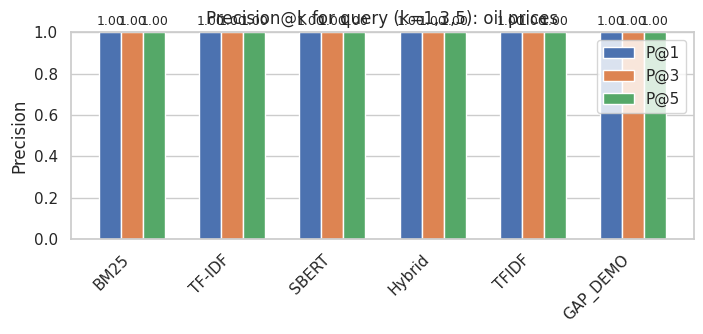

,system,ranked,P@1,P@3,P@5,nDCG@10,AP,missing_qrel
0,BM25,"[test/17441, training/127, training/352, test/...",1.0,1.0,1.0,1.0,1.0,False
1,TF-IDF,"[training/352, training/11118, training/11149,...",1.0,1.0,1.0,1.0,1.0,False
2,SBERT,"[training/10228, test/18085, training/11118, t...",1.0,1.0,1.0,1.0,1.0,False
3,Hybrid,"[test/20944, test/17441, training/3354, traini...",1.0,1.0,1.0,1.0,1.0,False
4,TFIDF,"[training/352, training/11118, training/11149,...",1.0,1.0,1.0,1.0,1.0,False
5,GAP_DEMO,"[test/15351, test/15607, test/14892, test/1523...",1.0,1.0,1.0,1.0,1.0,False


In [ ]:
run_custom_query_debug("oil prices")

In [ ]:
# Robust custom-query runner that builds a temporary qrel if none exists.
# Paste and run this cell, then call run_custom_query_any("your query").

import numpy as np, math
import matplotlib.pyplot as plt
from math import isfinite

def _safe_call(fn, q, top_k=20):
    try:
        out = fn(q, top_k=top_k)
        if out is None:
            return None, "FN_RETURNED_NONE"
        if isinstance(out, tuple) and len(out) >= 1:
            ranked = out[0]
        elif isinstance(out, list):
            ranked = out
        else:
            ranked = list(out)
        return ranked, None
    except Exception as e:
        return None, str(e)

def _make_pseudo_qrel_sbert(q, top_k_rel=10):
    """Return set(doc_id) = top_k_rel documents by SBERT similarity (semantic pseudo-qrel)."""
    if 'retrieve_sbert_docs' in globals():
        ranked, sims = retrieve_sbert_docs(q, top_k=top_k_rel)
        return set(ranked[:top_k_rel])
    else:
        # fallback: use BM25 top-K if sbert not available
        ranked, _ = retrieve_bm25_docs(q, top_k=top_k_rel)
        return set(ranked[:top_k_rel])

def _make_pseudo_qrel_token_overlap(q, min_overlap=2, max_docs=200):
    """Return set(doc_id) of docs that share at least min_overlap query tokens (lexical pseudo-qrel)."""
    q_toks = set(simple_tokenize(q))
    hits = []
    for i, toks in enumerate(docs_tokens):
        overlap = len(q_toks.intersection(set(toks)))
        if overlap >= min_overlap:
            hits.append(doc_id_list[i])
            if len(hits) >= max_docs:
                break
    return set(hits)

def run_custom_query_any(q, top_k=20, show_snip_len=200, save_plot=True,
                         rel_method='sbert_topk', top_k_rel=10, min_overlap=2):
    """
    Run an arbitrary free-text query. If gold qrel exists (exact key in qrels), use it.
    Otherwise construct a temporary pseudo-qrel using rel_method:
      - 'sbert_topk' : mark top_k_rel docs by SBERT similarity as relevant (default).
      - 'token_overlap' : mark docs with >= min_overlap shared tokens as relevant.
    Returns DataFrame of per-system metrics and prints snippets + plot.
    """
    # detect retrieval functions
    system_funcs = []
    if 'retrieve_bm25_docs' in globals(): system_funcs.append(('BM25', retrieve_bm25_docs))
    if 'retrieve_tfidf_docs' in globals(): system_funcs.append(('TF-IDF', retrieve_tfidf_docs))
    if 'retrieve_sbert_docs' in globals(): system_funcs.append(('SBERT', retrieve_sbert_docs))
    if 'hybrid_bm25_sbert_rerank' in globals(): system_funcs.append(('Hybrid', hybrid_bm25_sbert_rerank))
    if 'ltr_wrapper' in globals(): system_funcs.append(('LTR', ltr_wrapper))
    # fallback: pick up any retrieve_* callable
    for name, val in list(globals().items()):
        if name.startswith('retrieve_') and callable(val):
            short = name.replace('retrieve_','').replace('_docs','').upper()
            if all(short != s[0] for s in system_funcs):
                system_funcs.append((short, val))
    if not system_funcs:
        print("No retrieval functions found. Define retrieve_bm25_docs / retrieve_sbert_docs / hybrid..."); return None

    print(f"\nRunning query: {q!r}  (top_k={top_k})")
    gold_qrel = qrels.get(q, None) if 'qrels' in globals() else None
    pseudo_used = False
    if gold_qrel is None:
        # create pseudo qrel
        pseudo_used = True
        if rel_method == 'sbert_topk':
            temp_qrel = _make_pseudo_qrel_sbert(q, top_k_rel=top_k_rel)
            rel_note = f"pseudo-qrel via SBERT top-{top_k_rel}"
        elif rel_method == 'token_overlap':
            temp_qrel = _make_pseudo_qrel_token_overlap(q, min_overlap=min_overlap)
            rel_note = f"pseudo-qrel via token overlap >= {min_overlap}"
        else:
            print("Unknown rel_method:", rel_method, " — using sbert_topk fallback")
            temp_qrel = _make_pseudo_qrel_sbert(q, top_k_rel=top_k_rel)
            rel_note = f"pseudo-qrel via SBERT top-{top_k_rel}"
        print("WARNING: no gold qrel for this query. Using", rel_note, " — treat metrics as approximate.")
        rel_set = temp_qrel
    else:
        rel_set = set(gold_qrel)

    rows = []
    any_metrics = False
    for name, fn in system_funcs:
        ranked, err = _safe_call(fn, q, top_k=top_k)
        if err:
            print(f"[{name}] ERROR -> {err}")
            rows.append({'system':name, 'error':err})
            continue
        if not ranked:
            print(f"[{name}] returned zero results.")
            rows.append({'system':name, 'error':'no_results'})
            continue

        # compute metrics vs rel_set
        p1 = precision_at_k(ranked, rel_set, 1)
        p3 = precision_at_k(ranked, rel_set, 3)
        p5 = precision_at_k(ranked, rel_set, 5)
        n10 = ndcg_at_k(ranked, rel_set, 10)
        ap = average_precision(ranked, rel_set)
        any_metrics = True

        # print snippets
        print(f"\n--- {name} top-{min(5,len(ranked))} ---")
        for i, did in enumerate(ranked[:5], 1):
            idx = docid_to_index.get(did, None)
            snippet = df.loc[idx,'text'][:show_snip_len].replace("\n"," ") if idx is not None else f"(doc {did} not in df)"
            print(f"{i}. {did} | {snippet[:400]}")
        rows.append({'system':name, 'ranked':ranked, 'P@1':float(p1), 'P@3':float(p3), 'P@5':float(p5), 'nDCG@10':float(n10), 'AP':float(ap)})

    df_results = pd.DataFrame(rows)
    if df_results.empty:
        print("No results to show (unexpected)."); return df_results

    # plotting (convert numeric missing -> 0)
    labels = df_results['system'].tolist()
    p1 = [ (float(v) if (v is not None and isfinite(float(v))) else 0.0) for v in df_results.get('P@1', [None]*len(labels)) ]
    p3 = [ (float(v) if (v is not None and isfinite(float(v))) else 0.0) for v in df_results.get('P@3', [None]*len(labels)) ]
    p5 = [ (float(v) if (v is not None and isfinite(float(v))) else 0.0) for v in df_results.get('P@5', [None]*len(labels)) ]

    x = np.arange(len(labels)); width = 0.22
    plt.figure(figsize=(max(6,len(labels)*1.2),4))
    b1 = plt.bar(x - width, p1, width, label='P@1')
    b2 = plt.bar(x, p3, width, label='P@3')
    b3 = plt.bar(x + width, p5, width, label='P@5')
    plt.xticks(x, labels, rotation=45, ha='right'); plt.ylim(0,1.0)
    plt.title(f"Precision@k for query: {q[:90]}")
    plt.ylabel("Precision")
    plt.legend()
    # annotate
    for bar, val in zip(b1, p1):
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f"{val:.2f}", ha='center', fontsize=9)
    for bar, val in zip(b2, p3):
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f"{val:.2f}", ha='center', fontsize=9)
    for bar, val in zip(b3, p5):
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f"{val:.2f}", ha='center', fontsize=9)

    plt.tight_layout()
    if save_plot:
        fname_safe = "".join([c if c.isalnum() or c in "-_ " else "_" for c in q])[:60].replace(" ","_")
        fname = f"assignment_outputs/custom_query_any_{fname_safe}.png"
        try:
            plt.savefig(fname, bbox_inches='tight')
            print("Saved plot to:", fname)
        except Exception as e:
            print("Warning: failed to save plot:", e)
    plt.show()

    return df_results


Running query: 'dfl'  (top_k=20)

--- BM25 top-5 ---
1. training/999 | U.K. MONEY MARKET SHORTAGE FORECAST REVISED DOWN   The Bank of England said it had revised   its forecast of the shortage in the money market down to 450   mln stg before taking account of its morning
2. training/9989 | SENATE SEEKS U.S. PROBE OF CANADIAN CORN LEVY   The Senate voted unanimously to seek   an expedited U.S. probe of Canadian tariffs on corn imports to   determine if the United States should retaliate.
3. training/9988 | FED SETS TWO BILLION DLR CUSTOMER REPURCHASE   The Federal Reserve entered the U.S.   government securities market to arrange two billion dlrs of   customer repurchase agreements, a spokeswoman for th
4. training/9985 | AVERY &lt;AVY> 1ST QTR FEB 28 NET   Shr 33 cts vs 30 cts       Net 13.0 mln vs 11.9 mln       Sales 330.8 mln vs 249.7 mln     
5. training/9984 | KODAK &lt;EK> BUYS STAKE IN BIOTECHNOLOGY COMPANY   Eastman Kodak Co said it has   reached an agreement to acquire new st

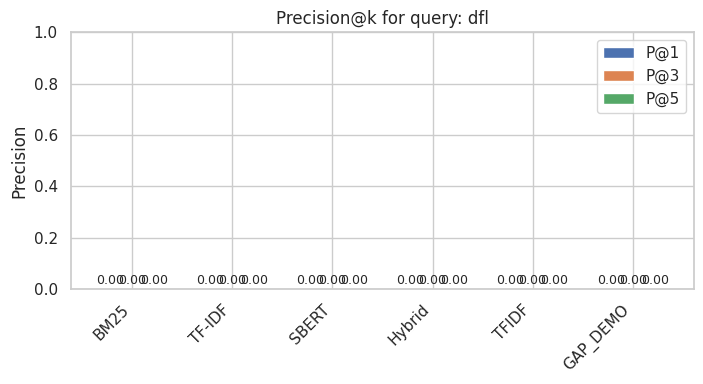


Running query: 'oil prices'  (top_k=20)

--- BM25 top-5 ---
1. test/17441 | SINGAPORE OIL COMPANIES TO SET OWN PUMP PRICES   Singapore oil companies can set their   own petrol and diesel prices at the pump from today subject to   ceilings determined by their individual wholes
2. training/127 | DIAMOND SHAMROCK (DIA) CUTS CRUDE PRICES   Diamond Shamrock Corp said that   effective today it had cut its contract prices for crude oil by   1.50 dlrs a barrel.       The reduction brings its posted
3. training/352 | SAUDI ARABIA REITERATES COMMITMENT TO OPEC ACCORD   Saudi Arabian Oil Minister Hisham Nazer   reiterated the kingdom's commitment to last December's OPEC   accord to boost world oil prices and stabili
4. test/20944 | ARCO RAISES CRUDE OIL PRICES 50 CTS BARREL, TODAY, WTI TO 19.00    ARCO RAISES CRUDE OIL PRICES 50 CTS BARREL, TODAY, WTI TO 19.00     
5. training/3354 | CONOCO RAISES CRUDE OIL PRICES UP TO ONE DLR BARREL, WTI AT 17.50 DLRS    CONOCO RAISES CRUDE OIL PRICES UP TO ON

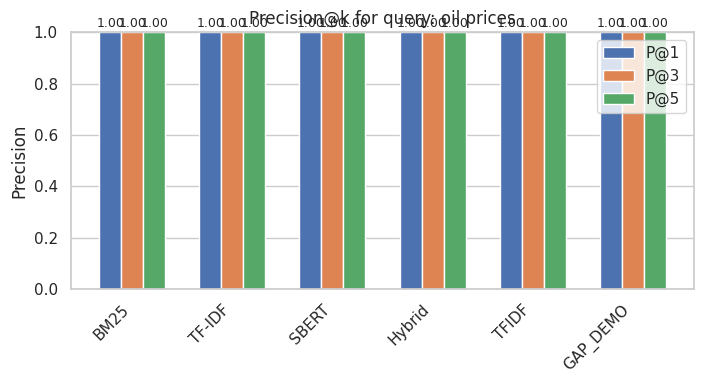


Running query: 'oil prices'  (top_k=20)

--- BM25 top-5 ---
1. test/17441 | SINGAPORE OIL COMPANIES TO SET OWN PUMP PRICES   Singapore oil companies can set their   own petrol and diesel prices at the pump from today subject to   ceilings determined by their individual wholes
2. training/127 | DIAMOND SHAMROCK (DIA) CUTS CRUDE PRICES   Diamond Shamrock Corp said that   effective today it had cut its contract prices for crude oil by   1.50 dlrs a barrel.       The reduction brings its posted
3. training/352 | SAUDI ARABIA REITERATES COMMITMENT TO OPEC ACCORD   Saudi Arabian Oil Minister Hisham Nazer   reiterated the kingdom's commitment to last December's OPEC   accord to boost world oil prices and stabili
4. test/20944 | ARCO RAISES CRUDE OIL PRICES 50 CTS BARREL, TODAY, WTI TO 19.00    ARCO RAISES CRUDE OIL PRICES 50 CTS BARREL, TODAY, WTI TO 19.00     
5. training/3354 | CONOCO RAISES CRUDE OIL PRICES UP TO ONE DLR BARREL, WTI AT 17.50 DLRS    CONOCO RAISES CRUDE OIL PRICES UP TO ON

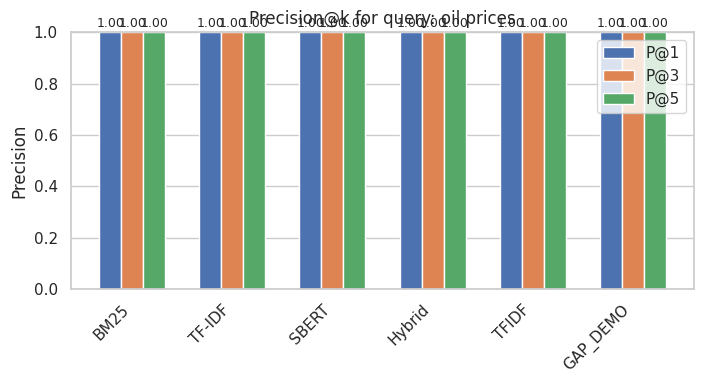

,system,ranked,P@1,P@3,P@5,nDCG@10,AP
0,BM25,"[test/17441, training/127, training/352, test/...",1.0,1.0,1.0,1.0,1.000000
1,TF-IDF,"[training/352, training/11118, training/11149,...",1.0,1.0,1.0,1.0,1.000000
2,SBERT,"[training/10228, test/18085, training/11118, t...",1.0,1.0,1.0,1.0,1.000000
3,Hybrid,"[test/18066, training/11723, test/20944, test/...",1.0,1.0,1.0,1.0,1.000000
4,TFIDF,"[training/352, training/11118, training/11149,...",1.0,1.0,1.0,1.0,1.000000
5,GAP_DEMO,"[test/15351, test/15607, test/14892, test/1523...",1.0,1.0,1.0,1.0,0.994444


In [ ]:
# recommended examples
run_custom_query_any(queries[0])                      # a generated query with gold qrel
run_custom_query_any("oil prices")                    # free-text: will use pseudo-qrel by default (sbert_topk)
run_custom_query_any("oil prices", rel_method='token_overlap', min_overlap=2)

In [ ]:
# Debug helper: check required objects and show qrels info for a query
def custom_query_debug_check(query):
    needed = ['df','docid_to_index','queries','qrels','retrieve_bm25_docs','retrieve_sbert_docs','hybrid_bm25_sbert_rerank',
              'precision_at_k','ndcg_at_k','average_precision']
    print("Checking required objects:")
    for name in needed:
        print(f"  {name:30s} -> {'OK' if name in globals() else 'MISSING'}")
    print("\nAvailable retrieve_* functions in globals():")
    for n in sorted([k for k in globals().keys() if k.startswith('retrieve_')]):
        print("  ", n)
    # Query presence in qrels
    has_qrel = (query in qrels) if 'qrels' in globals() else False
    print(f"\nQuery provided: {query!r}")
    print("Is query in qrels map?:", has_qrel)
    if has_qrel:
        print("Number of qrel docs:", len(qrels[query]))
        print("Sample qrel docs:", list(qrels[query])[:6])
    else:
        # show similar keys (helpful if query text differs)
        if 'qrels' in globals():
            sample_keys = list(qrels.keys())[:20]
            print("qrels sample keys (first 20):")
            for k in sample_keys:
                print("  ", repr(k)[:80])
    # show a quick retrieval snippet from BM25 if available
    if 'retrieve_bm25_docs' in globals():
        try:
            ranked, _ = retrieve_bm25_docs(query, top_k=5)
            print("\nBM25 top-5 docids:", ranked)
            if ranked:
                idx = docid_to_index.get(ranked[0], None)
                if idx is not None:
                    print("BM25 top-1 snippet:", df.loc[idx,'text'][:200].replace("\n"," "))
        except Exception as e:
            print("BM25 call error:", e)

# Example usage: run this check for the query you will test
# custom_query_debug_check(queries[0])

In [ ]:
# Debug checklist — run this cell
needed = ['df','docid_to_index','queries','qrels','retrieve_bm25_docs','retrieve_sbert_docs','hybrid_bm25_sbert_rerank',
          'precision_at_k','ndcg_at_k','average_precision']
for name in needed:
    ok = name in globals()
    print(f"{name:30s} -> {'OK' if ok else 'MISSING'}")
# show sample query and qrels sizes
print("\nSample queries (first 5):", queries[:5] if 'queries' in globals() else "no queries")
if 'qrels' in globals():
    sample = list(qrels.items())[:5]
    print("\nSample qrels (query : #docs):")
    for q,v in sample:
        print(f"  {q[:60]:60s} : {len(v)}")
# check docid mapping
if 'docid_to_index' in globals() and 'df' in globals():
    some_doc = df['doc_id'].iloc[0]
    print("\nExample doc mapping:", some_doc, "->", docid_to_index.get(some_doc))

df                             -> OK
docid_to_index                 -> OK
queries                        -> OK
qrels                          -> OK
retrieve_bm25_docs             -> OK
retrieve_sbert_docs            -> OK
hybrid_bm25_sbert_rerank       -> OK
precision_at_k                 -> OK
ndcg_at_k                      -> OK
average_precision              -> OK

Sample queries (first 5): ['dfl', 'FRENCH JANUARY PAYMENTS SURPLUS 0.3 BILLION FRANCS (3.8 BILLION DECEMBER SURPLUS)-OFFICIAL\n\n  FRENCH JANUARY PAYMENTS SU', 'bank profits', 'oilseed', 'soy oil']

Sample qrels (query : #docs):
  dfl                                                          : 3
  oilseed                                                      : 171
  cocoa                                                        : 73
  alum                                                         : 58
  platinum                                                     : 12

Example doc mapping: test/14826 -> 0


In [ ]:
# Robust custom query runner — paste and run this cell, then call run_custom_query("your query here")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import isfinite

def _safe_call(fn, q, top_k=20):
    try:
        out = fn(q, top_k=top_k)
        # allow retrieve functions that return (ranked, scores) or just ranked list
        if out is None:
            return None, "FN_RETURNED_NONE"
        if isinstance(out, tuple) and len(out) >= 1:
            ranked = out[0]
            scores = out[1] if len(out) > 1 else None
        elif isinstance(out, list):
            ranked = out
            scores = None
        else:
            ranked = list(out)
            scores = None
        return ranked, None
    except Exception as e:
        return None, str(e)

def run_custom_query(q, top_k=10, show_snip_len=200, save_plot=True):
    """
    Run a custom query through available retrieval systems, print metrics & top-k snippets.
    Returns a dataframe with per-system metrics (or None if metrics unavailable).
    """
    # detect available systems (common names used in this notebook)
    system_funcs = []
    if 'retrieve_bm25_docs' in globals():
        system_funcs.append(('BM25', retrieve_bm25_docs))
    elif 'retrieve_bm25' in globals():
        system_funcs.append(('BM25', retrieve_bm25))
    if 'retrieve_tfidf_docs' in globals():
        system_funcs.append(('TF-IDF', retrieve_tfidf_docs))
    elif 'tfidf' in globals():
        # we won't attempt if no wrapper
        pass
    if 'retrieve_sbert_docs' in globals():
        system_funcs.append(('SBERT', retrieve_sbert_docs))
    elif 'retrieve_sbert' in globals():
        system_funcs.append(('SBERT', retrieve_sbert))
    if 'hybrid_bm25_sbert_rerank' in globals():
        system_funcs.append(('Hybrid', hybrid_bm25_sbert_rerank))
    elif 'hybrid_retrieve_and_rerank' in globals():
        system_funcs.append(('Hybrid', hybrid_retrieve_and_rerank))
    if 'ltr_wrapper' in globals():
        system_funcs.append(('LTR', ltr_wrapper))
    # fallback: any functions named retrieve_* in globals
    for name, val in list(globals().items()):
        if name.startswith('retrieve_') and callable(val):
            short = name.replace('retrieve_','').replace('_docs','').upper()
            if all(short != s[0] for s in system_funcs):
                system_funcs.append((short, val))

    if not system_funcs:
        print("No retrieval functions found. Make sure you ran the cells that define retrieval wrappers (e.g., retrieve_bm25_docs, retrieve_sbert_docs, hybrid...).")
        return None

    # header
    print(f"\nRunning custom query (top_k={top_k}):\n  {q}\n")
    rows = []
    for name, fn in system_funcs:
        ranked, err = _safe_call(fn, q, top_k=top_k)
        if err:
            print(f"[{name}] ERROR -> {err}\n")
            rows.append({'system':name, 'error':str(err)})
            continue
        if not ranked or len(ranked)==0:
            print(f"[{name}] returned zero ranked docs.\n")
            rows.append({'system':name, 'error':'no_results'})
            continue

        # compute metrics only if qrels present
        rel = qrels.get(q, None)
        metrics = {}
        if rel is None:
            # No qrel for this exact custom query; warn and compute only counts
            print(f"[{name}] (no qrels for this query => metrics will be omitted). Showing top {min(top_k,5)} docs below.")
            metrics = {'P@1':None,'P@3':None,'P@5':None,'nDCG@10':None,'AP':None}
        else:
            metrics = {
                'P@1': precision_at_k(ranked, rel, 1),
                'P@3': precision_at_k(ranked, rel, 3),
                'P@5': precision_at_k(ranked, rel, 5),
                'nDCG@10': ndcg_at_k(ranked, rel, 10),
                'AP': average_precision(ranked, rel)
            }

        # print small snippet list
        print(f"--- {name} (top {min(5, len(ranked))}) ---")
        for i, did in enumerate(ranked[:5], start=1):
            try:
                idx = docid_to_index.get(did, None)
                snippet = df.loc[idx, 'text'][:show_snip_len].replace("\n"," ") if idx is not None else f"(doc {did} not in df)"
            except Exception:
                snippet = "(unable to retrieve snippet)"
            print(f"{i}. {did} | {snippet}")
        print()
        r = {'system':name, 'ranked':ranked, **metrics}
        rows.append(r)

    # build DataFrame of metrics
    df_results = pd.DataFrame(rows)

    # plot P@1,P@3,P@5 if at least one system has numeric values
    numeric_exists = df_results[['P@1','P@3','P@5']].notnull().any().any() if {'P@1','P@3','P@5'}.issubset(df_results.columns) else False
    if numeric_exists:
        labels = df_results['system'].tolist()
        p1 = [0 if v is None or (not isfinite(v)) else v for v in df_results['P@1'].fillna(0).tolist()]
        p3 = [0 if v is None or (not isfinite(v)) else v for v in df_results['P@3'].fillna(0).tolist()]
        p5 = [0 if v is None or (not isfinite(v)) else v for v in df_results['P@5'].fillna(0).tolist()]

        x = np.arange(len(labels))
        width = 0.22
        plt.figure(figsize=(8,3))
        plt.bar(x - width, p1, width, label='P@1')
        plt.bar(x, p3, width, label='P@3')
        plt.bar(x + width, p5, width, label='P@5')
        plt.xticks(x, labels, rotation=45, ha='right')
        plt.ylim(0,1)
        plt.title(f"Precision@k for query (k=1,3,5)")
        plt.tight_layout()
        if save_plot:
            fname = f"assignment_outputs/custom_query_{q[:40].replace(' ','_')}.png"
            plt.savefig(fname, bbox_inches='tight')
            print(f"Saved precision plot -> {fname}")
        plt.show()
    else:
        print("No numeric metrics to plot (no qrels found for this query).")

    return df_results

# Example: run_custom_query("oil prices")
# After pasting cell, call like: run_custom_query("oil prices")


Running custom query (top_k=10):
  dfl

--- BM25 (top 5) ---
1. training/999 | U.K. MONEY MARKET SHORTAGE FORECAST REVISED DOWN   The Bank of England said it had revised   its forecast of the shortage in the money market down to 450   mln stg before taking account of its morning
2. training/9989 | SENATE SEEKS U.S. PROBE OF CANADIAN CORN LEVY   The Senate voted unanimously to seek   an expedited U.S. probe of Canadian tariffs on corn imports to   determine if the United States should retaliate.
3. training/9988 | FED SETS TWO BILLION DLR CUSTOMER REPURCHASE   The Federal Reserve entered the U.S.   government securities market to arrange two billion dlrs of   customer repurchase agreements, a spokeswoman for th
4. training/9985 | AVERY &lt;AVY> 1ST QTR FEB 28 NET   Shr 33 cts vs 30 cts       Net 13.0 mln vs 11.9 mln       Sales 330.8 mln vs 249.7 mln     
5. training/9984 | KODAK &lt;EK> BUYS STAKE IN BIOTECHNOLOGY COMPANY   Eastman Kodak Co said it has   reached an agreement to acquir

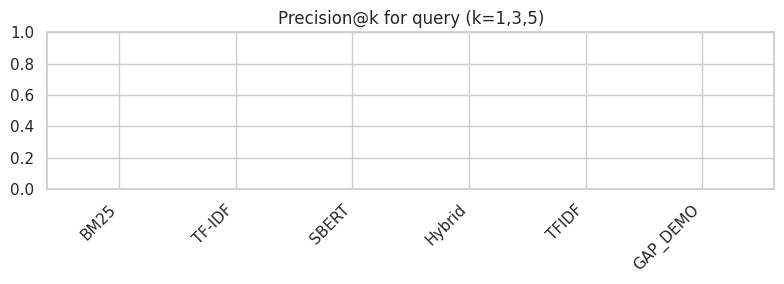


Running custom query (top_k=10):
  oil

[BM25] (no qrels for this query => metrics will be omitted). Showing top 5 docs below.
--- BM25 (top 5) ---
1. test/18678 | IMPERIAL OIL RAISES CRUDE OIL POSTINGS 32 CANADIAN CTS/BBL, LIGHT SWEET NOW 25.60     IMPERIAL OIL RAISES CRUDE OIL POSTINGS 32 CANADIAN   CTS/BBL, LIGHT SWEET NOW 25.60        
2. training/313 | DUTCH OILSEEDS/FATS IMPORTS ROSE IN 1986   and oil-bearing   raw materials, fats and oils rose to 2.16 mln tonnes on a   fat/oil basis in 1986 from 2.12 mln tonnes in 1985, the   Commodity Board for M
3. test/19223 | U.S. COURT UPHOLDS APEX DECISION FAVORING NYMEX   The U.S. Court of Appeals for the   Second Circuit upheld a lower court decision dismissing a suit   by Apex Oil Co against the New York Mercantile Ex
4. training/6119 | U.S. WARNS OF DEPENDENCE ON FOREIGN OIL   A White House-ordered report said    that growing U.S. reliance on foreign oil into the year 2000   could have potentially damaging implications for national 
5

,system,ranked,P@1,P@3,P@5,nDCG@10,AP
0,BM25,"[test/18678, training/313, test/19223, trainin...",None,None,None,None,None
1,TF-IDF,"[training/3798, training/6876, training/8478, ...",None,None,None,None,None
2,SBERT,"[training/8210, training/3364, training/5796, ...",None,None,None,None,None
3,Hybrid,"[test/18678, test/18857, training/6119, traini...",None,None,None,None,None
4,TFIDF,"[training/3798, training/6876, training/8478, ...",None,None,None,None,None
5,GAP_DEMO,"[test/15351, test/14892, test/15238, test/1506...",None,None,None,None,None


In [ ]:
run_custom_query(queries[0])
# or
run_custom_query("oil")

`CUSTOM QUERY CELLS`

In [ ]:
print("Interactive custom query demo. Enter empty input to exit.")
while True:
    q = input("\nEnter query: ").strip()
    if q == "":
        print("Exiting demo.")
        break
    systems = [("BM25", retrieve_bm25_docs), ("TF-IDF", retrieve_tfidf_docs), ("SBERT", retrieve_sbert_docs), ("Hybrid", hybrid_bm25_sbert_rerank)]
    results = []
    for name, fn in systems:
        ranked, _ = fn(q, top_k=20)
        rel = qrels.get(q, set())
        metrics = {'P@1': precision_at_k(ranked, rel, 1), 'P@3': precision_at_k(ranked, rel, 3), 'P@5': precision_at_k(ranked, rel, 5), 'P@10': precision_at_k(ranked, rel, 10), 'nDCG@10': ndcg_at_k(ranked, rel, 10), 'AP': average_precision(ranked, rel)}
        top_snips = [(i+1, did, df.loc[docid_to_index[did],'text'][:200].replace("\n"," ")) for i,did in enumerate(ranked[:5])]
        results.append((name, metrics, top_snips))
    # print summary
    for name, metrics, top_snips in results:
        print("\n---", name, "---")
        print(metrics)
        for s in top_snips:
            print(s[0], s[1], ":", s[2][:160])
    # plotting P@k bars
    labels = [r[0] for r in results]
    p1 = [r[1]['P@1'] for r in results]
    p3 = [r[1]['P@3'] for r in results]
    p5 = [r[1]['P@5'] for r in results]
    x = np.arange(len(labels))
    w = 0.2
    plt.figure(figsize=(8,3))
    plt.bar(x - w, p1, width=w, label='P@1')
    plt.bar(x, p3, width=w, label='P@3')
    plt.bar(x + w, p5, width=w, label='P@5')
    plt.xticks(x, labels)
    plt.ylim(0,1)
    plt.title(f"Precision for query: {q[:60]}")
    plt.legend()
    plt.show()

Interactive custom query demo. Enter empty input to exit.


KeyboardInterrupt: Interrupted by user

Batch run custom queries

In [ ]:
custom_list = queries[:12]  # you can replace with any list or read CSV
rows=[]
for q in tqdm(custom_list, desc="Batch custom queries"):
    for name, fn in [("BM25", retrieve_bm25_docs), ("SBERT", retrieve_sbert_docs), ("Hybrid", hybrid_bm25_sbert_rerank)]:
        ranked, _ = fn(q, top_k=100)
        rel = qrels.get(q, set())
        rows.append({'query':q,'system':name,'P@1':precision_at_k(ranked, rel, 1),'P@3':precision_at_k(ranked, rel, 3),
                     'P@5':precision_at_k(ranked, rel, 5),'P@10':precision_at_k(ranked, rel,10),'AP':average_precision(ranked,rel)})
batch_df = pd.DataFrame(rows)
batch_df.to_csv("assignment_outputs/custom_batch_results.csv", index=False)
print("Saved assignment_outputs/custom_batch_results.csv")
# pivot plot MAP by system
pivot = batch_df.groupby('system')['AP'].mean().reset_index()
plt.figure(figsize=(6,3)); plt.bar(pivot['system'], pivot['AP']); plt.title("Custom batch average AP by system"); plt.ylim(0,1); plt.show()